# Decision Boundary: XOR Problem — Fine-tuning TabICL

Compares vanilla TabICL vs fine-tuned TabICL on a 2D XOR classification task.

**Fine-tuning approach (same meta-learning style as TabICL training):**
1. Each epoch randomly splits training data into a context (support) set and a query set.
2. The model sees all rows as features, only context labels — same as in-context learning.
3. CrossEntropyLoss is computed on query predictions.
4. Gradients update only the unfrozen parameters.

**TabICL component map:**
| Component | Role |
|---|---|
| `col_embedder` | Column-wise (feature) embedding |
| `row_interactor` | Row-wise interaction between features |
| `icl_predictor` | In-context learning / output head |

In [49]:
import sys
sys.path.insert(0, "..")
sys.path.insert(0, "/home/amir/GitHub/looped_tfm/temp/tabicl/src")

import copy
import time
import warnings
from typing import Optional

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.optim import AdamW

warnings.filterwarnings("ignore")

## 1. Generate XOR dataset

In [ ]:
N_FEATURES = 10  # total number of features (checker label uses first 2; rest are noise)

def make_xor(n_samples: int = 400, noise: float = 0.01, n_features: int = N_FEATURES, random_state: int = 42, gap: float = 0.01):
    """Checkerboard classification with 2 grids per axis (4x4 tiles).
    First 2 features carry the signal; remaining features are Gaussian noise.
    Label = (floor(x1 * 2) mod 2) XOR (floor(x2 * 2) mod 2).
    gap: width of empty margin around each tile boundary (in data units)."""
    rng = np.random.default_rng(random_state)

    # Oversample then reject points too close to any tile boundary
    boundaries = np.array([-0.5, 0.0, 0.5])
    half_gap = gap / 2
    oversample_factor = int(np.ceil(1 / (1 - gap * len(boundaries)) ** 2)) + 2

    X_signal = rng.uniform(-1, 1, size=(n_samples * oversample_factor, 2))
    dist_x = np.min(np.abs(X_signal[:, 0:1] - boundaries), axis=1)
    dist_y = np.min(np.abs(X_signal[:, 1:2] - boundaries), axis=1)
    keep = (dist_x >= half_gap) & (dist_y >= half_gap)
    X_signal = X_signal[keep][:n_samples]

    # 2-period checkerboard: divide each axis into 4 equal bands
    grid_x = np.floor(X_signal[:, 0] * 2).astype(int) % 2
    grid_y = np.floor(X_signal[:, 1] * 2).astype(int) % 2
    y = (grid_x ^ grid_y).astype(int)
    X_signal += rng.normal(0, noise, size=X_signal.shape)

    if n_features > 2:
        X_noise = rng.normal(0, 0.5, size=(len(X_signal), n_features - 2))
        X = np.concatenate([X_signal, X_noise], axis=1)
    else:
        X = X_signal

    return X.astype(np.float32), y


X, y = make_xor()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

print(f"Features: {X.shape[1]} | Train: {len(X_tr)} | Val: {len(X_val)} | Test: {len(X_test)}")

fig, ax = plt.subplots(figsize=(4, 4))

# Shade true decision regions
res = 300
xx, yy = np.meshgrid(np.linspace(-1, 1, res), np.linspace(-1, 1, res))
zz = ((np.floor(xx * 2).astype(int) % 2) ^ (np.floor(yy * 2).astype(int) % 2)).astype(float)
ax.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5], colors=["#aec6e8", "#f5a8a8"], alpha=0.4)

# True boundary lines
for v in [-0.5, 0.0, 0.5]:
    ax.axvline(v, color="k", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.axhline(v, color="k", linewidth=0.8, linestyle="--", alpha=0.6)

ax.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k", linewidths=0.3, s=25, alpha=0.8)
ax.set_title(f"Checkerboard dataset (2 grids, showing x1, x2 of {X.shape[1]} features)")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
plt.tight_layout()
plt.show()

## 2. Helper: plot decision boundary

In [51]:
def plot_decision_boundary(clf, X, y, ax, title, resolution=30):
    """Fill a 2D decision boundary for a binary classifier.
    Sweeps over the first two features; all remaining features are fixed at 0."""
    x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
    y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, resolution),
        np.linspace(y_min, y_max, resolution),
    )
    grid_2d = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

    # Pad extra features with zeros so the classifier sees the right shape
    n_features = X.shape[1]
    if n_features > 2:
        padding = np.zeros((len(grid_2d), n_features - 2), dtype=np.float32)
        grid = np.concatenate([grid_2d, padding], axis=1)
    else:
        grid = grid_2d

    proba = clf.predict_proba(grid)[:, 1]  # P(class = 1)
    Z = proba.reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=50, cmap=plt.cm.RdBu_r, alpha=0.75, vmin=0, vmax=1)
    ax.contour(xx, yy, Z, levels=[0.5], colors="k", linewidths=1.2)

    colors = np.where(y == 1, "#d62728", "#1f77b4")
    ax.scatter(X[:, 0], X[:, 1], c=colors, edgecolors="w", linewidths=0.4, s=30, zorder=3)

    acc = (clf.predict(X) == y).mean()
    ax.set_title(f"{title}\nacc={acc:.3f}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

## 3. Cosine warmup scheduler

In [52]:
class CosineWarmupScheduler(torch.optim.lr_scheduler.LambdaLR):
    """Linear warmup followed by cosine decay."""

    def __init__(self, optimizer, warmup_steps: int, total_steps: int):
        def lr_lambda(step: int) -> float:
            if step < warmup_steps:
                return float(step) / max(1, warmup_steps)
            progress = float(step - warmup_steps) / max(1, total_steps - warmup_steps)
            return max(0.0, 0.5 * (1.0 + np.cos(np.pi * progress)))

        super().__init__(optimizer, lr_lambda)

## 4. TabICL Finetuner

In [53]:
class TabICLFinetuner:
    """Fine-tune TabICL on a single dataset using the same meta-learning setup
    as TabICL's original training:

    Each epoch splits training data into context (support) and query sets.
    The model sees all rows as features with only context labels visible.
    Loss is computed on query predictions and backpropagated.

    TabICL component map:
      col_embedder   — column-wise (feature) embedding
      row_interactor — row-wise interaction between features per row
      icl_predictor  — in-context learning predictor / output head

    Parameters
    ----------
    epochs : int
        Number of training epochs.
    learning_rate : float
        AdamW learning rate. Small values (1e-5 to 1e-4) are recommended.
    query_ratio : float
        Fraction of training samples used as the query set per epoch.
    weight_decay : float
        AdamW weight decay.
    grad_clip : float
        Max gradient norm (0 = disabled).
    freeze_col_embedder : bool
        Freeze the column-wise embedding transformer.
    freeze_row_interactor : bool
        Freeze the row-wise interaction transformer.
    freeze_icl_predictor : bool
        Freeze the in-context learning predictor head.
    warmup_proportion : float
        Fraction of total steps used for LR warmup.
    patience : int
        Early-stopping patience (epochs without val accuracy improvement).
    device : str
        Compute device ("cuda" or "cpu").
    random_state : int
        Seed for context/query splits.
    verbose : bool
        Print per-epoch progress.
    """

    def __init__(
        self,
        *,
        epochs: int = 20,
        learning_rate: float = 1e-5,
        query_ratio: float = 0.2,
        weight_decay: float = 0.01,
        grad_clip: float = 1.0,
        freeze_col_embedder: bool = False,
        freeze_row_interactor: bool = False,
        freeze_icl_predictor: bool = False,
        warmup_proportion: float = 0.1,
        patience: int = 8,
        device: str = "cuda",
        random_state: int = 42,
        verbose: bool = True,
    ):
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.query_ratio = query_ratio
        self.weight_decay = weight_decay
        self.grad_clip = grad_clip
        self.freeze_col_embedder = freeze_col_embedder
        self.freeze_row_interactor = freeze_row_interactor
        self.freeze_icl_predictor = freeze_icl_predictor
        self.warmup_proportion = warmup_proportion
        self.patience = patience
        self.device = device
        self.random_state = random_state
        self.verbose = verbose

        self._label_encoder: Optional[LabelEncoder] = None
        self._clf = None
        self.history: dict = {}

    # ------------------------------------------------------------------
    # Public API
    # ------------------------------------------------------------------

    def fit(
        self,
        X_train: np.ndarray,
        y_train: np.ndarray,
        X_val: np.ndarray,
        y_val: np.ndarray,
    ) -> "TabICLFinetuner":
        """Fine-tune TabICL on (X_train, y_train), evaluate on (X_val, y_val)."""
        # 1. Encode labels
        self._label_encoder = LabelEncoder()
        y_enc = self._label_encoder.fit_transform(y_train)
        y_val_enc = self._label_encoder.transform(y_val)

        # 2. Load pretrained TabICL and set up preprocessing
        model, clf = self._load_pretrained(X_train, y_train)
        model = model.to(self.device)
        model.train()

        # 3. Preprocess features (identity for numerical numpy arrays)
        X_tr_num = clf.X_encoder_.transform(X_train).astype(np.float32)
        X_val_num = clf.X_encoder_.transform(X_val).astype(np.float32)

        # 4. Freeze selected components
        self._apply_freezing(model)

        # 5. Optimizer + scheduler
        trainable = [p for p in model.parameters() if p.requires_grad]
        if not trainable:
            raise RuntimeError("All parameters frozen — nothing to fine-tune.")
        optimizer = AdamW(trainable, lr=self.learning_rate, weight_decay=self.weight_decay)
        total_steps = self.epochs
        warmup_steps = max(1, int(total_steps * self.warmup_proportion))
        scheduler = CosineWarmupScheduler(optimizer, warmup_steps, total_steps)

        # 6. Baseline validation
        model.eval()
        best_val_acc, best_val_loss = self._validate(model, X_tr_num, y_enc, X_val_num, y_val_enc)
        best_state = copy.deepcopy(model.state_dict())
        if self.verbose:
            print(f"  [finetune] baseline val_acc={best_val_acc:.4f} | val_loss={best_val_loss:.4f}")

        train_losses, val_losses, val_accs = [], [], []

        # 7. Training loop
        patience_counter = 0
        for epoch in range(self.epochs):
            model.train()
            t0 = time.perf_counter()
            train_loss = self._train_epoch(model, optimizer, X_tr_num, y_enc, epoch)
            scheduler.step()

            model.eval()
            val_acc, val_loss = self._validate(model, X_tr_num, y_enc, X_val_num, y_val_enc)
            elapsed = time.perf_counter() - t0

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            val_accs.append(val_acc)

            if self.verbose:
                print(
                    f"  [finetune] epoch {epoch+1:3d}/{self.epochs} | "
                    f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
                    f"val_acc={val_acc:.4f} | time={elapsed:.1f}s"
                )

            if val_acc > best_val_acc + 1e-4:
                best_val_acc = val_acc
                best_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= self.patience:
                    if self.verbose:
                        print(f"  [finetune] early stopping at epoch {epoch+1}")
                    break

        # 8. Restore best weights
        model.load_state_dict(best_state)
        model.eval()
        if self.verbose:
            print(f"  [finetune] best val_acc={best_val_acc:.4f}")

        self.history = {"train_loss": train_losses, "val_loss": val_losses, "val_acc": val_accs}

        # 9. Build inference classifier with fine-tuned weights
        clf.model_.load_state_dict(model.state_dict())
        clf.model_.eval()
        self._clf = clf
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        if self._clf is None:
            raise RuntimeError("Call fit() before predict().")
        return self._clf.predict(X)

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        if self._clf is None:
            raise RuntimeError("Call fit() before predict_proba().")
        return self._clf.predict_proba(X)

    def plot_history(self) -> None:
        if not self.history:
            raise RuntimeError("No history. Call fit() first.")

        epochs = range(1, len(self.history["train_loss"]) + 1)
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].plot(epochs, self.history["train_loss"], label="Train Loss", marker="o", markersize=3)
        axes[0].plot(epochs, self.history["val_loss"],   label="Val Loss",   marker="o", markersize=3)
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Cross-Entropy Loss")
        axes[0].set_title("Training vs Validation Loss")
        axes[0].legend()
        axes[0].grid(True)

        axes[1].plot(epochs, self.history["val_acc"], label="Val Accuracy", color="green", marker="o", markersize=3)
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy")
        axes[1].set_title("Validation Accuracy per Epoch")
        axes[1].legend()
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()
        plt.close()

    # ------------------------------------------------------------------
    # Internal helpers
    # ------------------------------------------------------------------

    def _load_pretrained(self, X_train, y_train):
        """Load TabICL via TabICLClassifier.fit() to initialise all preprocessing.

        Returns (raw TabICL nn.Module, fitted TabICLClassifier).
        """
        from tabicl import TabICLClassifier

        # Use a single estimator with no augmentation so the preprocessing
        # is deterministic and easy to replicate in the fine-tuning loop.
        clf = TabICLClassifier(
            n_estimators=1,
            norm_methods=["none"],
            feat_shuffle_method="none",
            class_shuffle_method="none",
            device=self.device,
        )
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            clf.fit(X_train, y_train)

        model = clf.model_
        return model, clf

    def _apply_freezing(self, model: nn.Module) -> None:
        """Disable gradients for selected top-level sub-modules."""
        frozen = 0
        components = [
            (self.freeze_col_embedder,   "col_embedder"),
            (self.freeze_row_interactor, "row_interactor"),
            (self.freeze_icl_predictor,  "icl_predictor"),
        ]
        for should_freeze, name in components:
            if should_freeze:
                module = getattr(model, name)
                for p in module.parameters():
                    p.requires_grad = False
                frozen += 1
        if self.verbose and frozen > 0:
            names = [n for f, n in components if f]
            print(f"  [finetune] frozen: {names}")

    def _make_meta_batch(
        self, X: np.ndarray, y: np.ndarray, epoch: int
    ):
        """Split data into context and query; return tensors in TabICL format.

        TabICL _train_forward expects:
          X       : (B, T, H)      float  — all rows (ctx first, then query)
          y_ctx   : (B, n_ctx)     float  — context labels only
          y_query : (n_query,)     long   — query targets for CE loss
        """
        rng = np.random.default_rng(self.random_state + epoch)
        n = len(X)
        n_query = max(1, int(n * self.query_ratio))

        idx = rng.permutation(n)
        query_idx, ctx_idx = idx[:n_query], idx[n_query:]

        X_all = np.concatenate([X[ctx_idx], X[query_idx]], axis=0)  # ctx first
        x_t = torch.tensor(X_all, dtype=torch.float32, device=self.device).unsqueeze(0)  # (1, T, H)
        y_ctx_t = torch.tensor(y[ctx_idx], dtype=torch.float32, device=self.device).unsqueeze(0)  # (1, n_ctx)
        y_query_t = torch.tensor(y[query_idx], dtype=torch.long, device=self.device)  # (n_query,)

        return x_t, y_ctx_t, y_query_t

    def _train_epoch(
        self, model: nn.Module, optimizer, X: np.ndarray, y: np.ndarray, epoch: int
    ) -> float:
        """One gradient update step using a single context/query split."""
        x_t, y_ctx_t, y_query_t = self._make_meta_batch(X, y, epoch)

        optimizer.zero_grad(set_to_none=True)

        # _train_forward: input (B, T, H), ctx labels (B, n_ctx) → output (B, n_query, n_classes)
        output = model._train_forward(x_t, y_ctx_t)  # (1, n_query, n_classes)
        logits = output[0]  # (n_query, n_classes)

        loss = nn.functional.cross_entropy(logits, y_query_t)

        if not torch.isfinite(loss):
            warnings.warn("Non-finite loss — skipping update.")
            return float("nan")

        loss.backward()

        if self.grad_clip > 0:
            nn.utils.clip_grad_norm_(model.parameters(), self.grad_clip)

        optimizer.step()
        return float(loss.detach().item())

    def _validate(
        self,
        model: nn.Module,
        X_train: np.ndarray,
        y_train_enc: np.ndarray,
        X_val: np.ndarray,
        y_val_enc: np.ndarray,
    ):
        """Validation: use all training data as context, val as query."""
        with torch.no_grad():
            X_all = np.concatenate([X_train, X_val], axis=0)
            x_t = torch.tensor(X_all, dtype=torch.float32, device=self.device).unsqueeze(0)  # (1, T, H)
            y_ctx_t = torch.tensor(y_train_enc, dtype=torch.float32, device=self.device).unsqueeze(0)  # (1, n_train)
            y_val_t = torch.tensor(y_val_enc, dtype=torch.long, device=self.device)

            # Call _train_forward explicitly to avoid inference-specific paths
            output = model._train_forward(x_t, y_ctx_t)  # (1, n_val, n_classes)
            logits = output[0]  # (n_val, n_classes)

            val_loss = float(nn.functional.cross_entropy(logits, y_val_t).item())
            preds = logits.argmax(dim=-1).cpu().numpy()

        val_acc = float((preds == y_val_enc).mean())
        return val_acc, val_loss

## 5. Vanilla TabICL (no fine-tuning)

In [59]:
from tabicl import TabICLClassifier

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

clf_vanilla = TabICLClassifier(
    n_estimators=1,
    norm_methods=["none"],
    feat_shuffle_method="none",
    class_shuffle_method="none",
    device=device,
    random_state=42,
)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    clf_vanilla.fit(X_tr, y_tr)

print(f"Vanilla TabICL test acc: {(clf_vanilla.predict(X_test) == y_test).mean():.4f}")

Using device: cpu
Vanilla TabICL test acc: 0.6100


## 6. Fine-tuned TabICL

In [60]:
finetuner = TabICLFinetuner(
    epochs=50,
    learning_rate=1e-4,
    query_ratio=0.3,
    freeze_col_embedder=False,
    freeze_row_interactor=False,
    freeze_icl_predictor=False,
    patience=20,
    device=device,
    verbose=True,
)
finetuner.fit(X_tr, y_tr, X_val, y_val)

  [finetune] baseline val_acc=0.6333 | val_loss=0.6669
  [finetune] epoch   1/50 | train_loss=0.6995 | val_loss=0.6669 | val_acc=0.6333 | time=0.8s
  [finetune] epoch   2/50 | train_loss=0.7056 | val_loss=0.6781 | val_acc=0.6500 | time=2.2s
  [finetune] epoch   3/50 | train_loss=0.6895 | val_loss=0.6839 | val_acc=0.4833 | time=1.8s
  [finetune] epoch   4/50 | train_loss=0.6845 | val_loss=0.7029 | val_acc=0.5167 | time=1.7s
  [finetune] epoch   5/50 | train_loss=0.7114 | val_loss=0.6907 | val_acc=0.5167 | time=1.8s
  [finetune] epoch   6/50 | train_loss=0.7262 | val_loss=0.6761 | val_acc=0.5833 | time=1.7s
  [finetune] epoch   7/50 | train_loss=0.6741 | val_loss=0.6700 | val_acc=0.5500 | time=1.6s
  [finetune] epoch   8/50 | train_loss=0.7311 | val_loss=0.6646 | val_acc=0.5167 | time=1.7s
  [finetune] epoch   9/50 | train_loss=0.6551 | val_loss=0.6294 | val_acc=0.6500 | time=1.8s
  [finetune] epoch  10/50 | train_loss=0.6846 | val_loss=0.5682 | val_acc=0.7667 | time=1.6s
  [finetune] ep

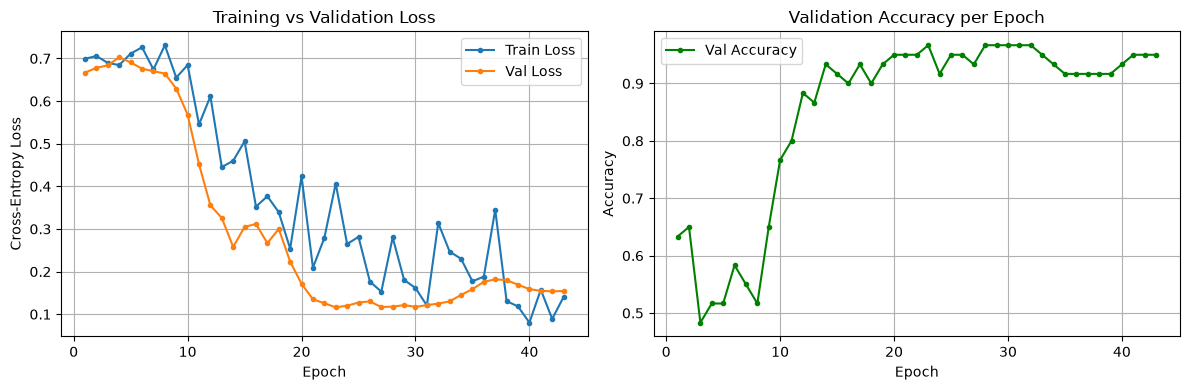

In [61]:
finetuner.plot_history()

In [62]:
print(f"Fine-tuned TabICL test acc: {(finetuner.predict(X_test) == y_test).mean():.4f}")

Fine-tuned TabICL test acc: 0.8900


## 7. Side-by-side decision boundary comparison

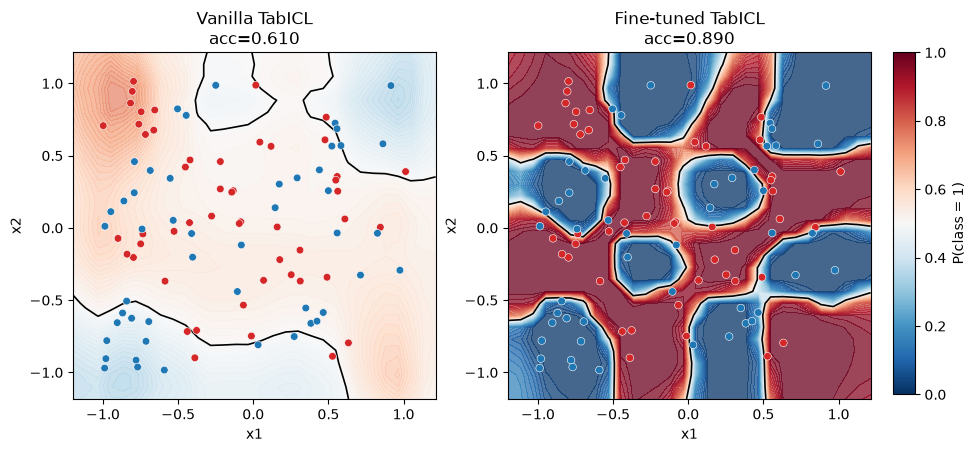

Saved to decision_boundary_xor_tabicl.png


In [63]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

plot_decision_boundary(clf_vanilla, X_test, y_test, axes[0], "Vanilla TabICL")
plot_decision_boundary(finetuner,   X_test, y_test, axes[1], "Fine-tuned TabICL")

sm = plt.cm.ScalarMappable(cmap=plt.cm.RdBu_r, norm=mcolors.Normalize(vmin=0, vmax=1))
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.87, 0.12, 0.02, 0.76])
fig.colorbar(sm, cax=cbar_ax, label="P(class = 1)")

#fig.suptitle("Decision Boundary on XOR Problem — TabICL", fontsize=13, fontweight="bold")
plt.show()
print("Saved to decision_boundary_xor_tabicl.png")